<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Clustering géographique des communes PV en PACA </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">


Ce notebook vise à identifier, à l'échelle de la région Provence-Alpes-Côte d'Azur **(PACA)**, des **communes représentatives** de la production photovoltaïque en combinant une analyse **géographique** et une **pondération énergétique**.

Après le chargement et le nettoyage des données issues du registre photovoltaïque et du référentiel INSEE des communes, l'énergie annuelle injectée est **agrégée par commune**. Ces données sont ensuite enrichies par les **coordonnées géographiques (latitude, longitude)** afin de permettre une analyse spatiale.

Un **clustering géographique** est réalisé à l'aide de l'algorithme **KMeans**, appliqué uniquement aux coordonnées **(latitude, longitude)**. Cela permet de découper la région **PACA** en plusieurs zones géographiques cohérentes, indépendamment du niveau de production énergétique.

Pour chaque cluster géographique, la **contribution énergétique totale** est calculée, ainsi que sa **part relative (%)** dans la production régionale. Cette information est utilisée pour caractériser le poids énergétique de chaque zone.

Dans chaque cluster, un **centre de gravité énergétique** est ensuite déterminé. Ce centroïde correspond à une moyenne pondérée des coordonnées géographiques des communes, les poids étant directement proportionnels à l'énergie injectée par chacune d'entre elles. Ce choix permet de préserver la hiérarchie physique entre territoires et d'obtenir un centroïde qui reflète fidèlement la contribution réelle de chaque commune au sein du cluster.

La **commune représentative** de chaque cluster est définie comme celle dont la position géographique est **la plus proche du centroïde énergétique**. Cette commune peut être interprétée comme un point spatialement central et énergétiquement significatif au sein de son cluster.

Enfin, les résultats sont **visualisés sur un fond de carte PACA** :
- les communes sont affichées avec une couleur correspondant à leur cluster,
- la taille des points est proportionnelle à leur énergie produite,
- les communes représentatives sont mises en évidence,
- les centroïdes KMeans sont également affichés.

Les résultats finaux sont sauvegardés dans un fichier CSV afin de permettre une exploitation ultérieure dans des autres notebooks.

**Résumé de la démarche**

1. Nettoyage et préparation des données (registre PV, communes INSEE, harmonisation des identifiants).
2. Sélection de l'indicateur énergétique principal (énergie injectée annuelle glissante).
3. Gestion explicite des données incomplètes (communes manquantes, énergie non renseignée).
4. Construction d'un espace géographique agrégé à la maille communale.
5. Clustering des communes (K = 5) pour définir des zones territoriales représentatives.
6. Calcul de centroïdes énergétiques pondérés par l'énergie injectée.
7. Sélection des communes représentatives au sein de chaque cluster.

### Imports
Import des bibliothèques nécessaires pour le traitement, le clustering et la cartographie.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd

### Chargement des données
Cette étape consiste à charger les fichiers CSV contenant le registre des installations photovoltaïques (registre PV issu d'ECO2mix) ainsi que les données des communes issues de l'INSEE.

Le registre PV comprend notamment les variables suivantes:

- **`idpeps`** : identifiant unique de l'installation de production d'électricité dans la base ECO2mix.  
- **`nominstallation`** : nom de l'installation de production d'électricité.  
- **`codeinseecommune`** : code INSEE de la commune de localisation de l'installation.  
- **`commune`** : nom de la commune où est située l'installation.  
- **`codeepci`** : code identifiant l'établissement public de coopération intercommunale (EPCI) auquel appartient la commune.  
- **`epci`** : nom de l'établissement public de coopération intercommunale (EPCI).  
- **`codeiriscommuneimplantation`** : code IRIS correspondant à la zone d'implantation de l'installation au sein de la commune.  
- **`codeinseecommuneimplantation`** : code INSEE de la commune d'implantation de l'installation, utilisé lorsque l'information diffère de la commune principale.
- **`filiere`** : filière énergétique de l'installation, ici exclusivement solaire (photovoltaïque).
- **`nbgroupes`** : nombre de groupes de production associés à l'installation (par exemple, nombre d'unités ou de sous-systèmes de production).  
- **`nbinstallations`** : nombre d'installations de production regroupées dans un même enregistrement.
- **`energieannuelleglissanteinjectee`** : énergie annuelle glissante injectée sur le réseau électrique, exprimée en kWh.  
- **`energieannuelleglissanteproduite`** : énergie annuelle glissante produite par l'installation, exprimée en KWh.



In [2]:
# Chargement du fichier contenant le registre brut des données photovoltaïques
registre = pd.read_csv("../../data/local_data/01_Clustering/input/registre_pv_paca_raw.csv")

# Chargement du fichier contenant les informations des communes de la région PACA (codes INSEE, noms, etc.)
communes = pd.read_csv("../../data/local_data/01_Clustering/input/communes_PACA_INSEE.csv")

# Affichage des 5 premières lignes du DataFrame registre pour un aperçu rapide des données
display(registre.head())

# Affichage d'un résumé du DataFrame registre
print(registre.info())

# Affichage des statistiques descriptives pour les variables numériques
registre.describe()


,idpeps,nominstallation,codeeicresourceobject,codeiris,codeinseecommune,commune,codeepci,epci,codedepartement,departement,...,productible,debitmaximal,codegestionnaire,gestionnaire,energieannuelleglissanteinjectee,energieannuelleglissanteproduite,energieannuelleglissantesoutiree,energieannuelleglissantestockee,maxpuis,datemiseenservice_date
0,17X100A100A0001A-50000368230799,FLORAME IR,17W0000016859889,131000104.0,13100.0,Saint-Rémy-de-Provence,241300375.0,CC Vallée des Baux-Alpilles (CC VBA),13.0,Bouches-du-Rhône,...,0.0,0.0,17X100A100A0001A,Enedis,270732.0,NaN,NaN,NaN,250.0,2023-12-12
1,17X100A100A0001A-50094291916870,LYRS - A.RENOIR 2- IR06SAK3130,17W0000021454106,NaN,6027.0,Cagnes-sur-Mer,200030195.0,Métropole Nice Côte d'Azur,6.0,Alpes-Maritimes,...,0.0,0.0,17X100A100A0001A,Enedis,104573.0,NaN,NaN,NaN,100.0,2024-12-11
2,17X100A100A0001A-50085317800019,SCI LES TOURNIAIRES 2,17W000002145414Z,NaN,4209.0,Sisteron,200068765.0,CC du Sisteronais-Buëch,4.0,Alpes-de-Haute-Provence,...,0.0,0.0,17X100A100A0001A,Enedis,304374.0,NaN,NaN,NaN,176.0,2024-12-04
3,17X100A100A0001A-50057387492368,OMBRIÈRES STM BUS,17W0000019957571,50610108.0,5061.0,Gap,200067825.0,CA Gap-Tallard-Durance,5.0,Hautes-Alpes,...,0.0,0.0,17X100A100A0001A,Enedis,347602.0,NaN,NaN,NaN,264.0,2024-05-29
4,17X100A100A0001A-30002560334140,RICHAUD FRUITS,17W0000016392053,42440000.0,4244.0,Volonne,200067437.0,CA Provence-Alpes-Agglomération,4.0,Alpes-de-Haute-Provence,...,0.0,0.0,17X100A100A0001A,Enedis,53650.0,NaN,NaN,NaN,90.0,2023-10-12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6498 entries, 0 to 6497
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   idpeps                            4669 non-null   object 
 1   nominstallation                   6498 non-null   object 
 2   codeeicresourceobject             4669 non-null   object 
 3   codeiris                          5125 non-null   float64
 4   codeinseecommune                  6453 non-null   float64
 5   commune                           6453 non-null   object 
 6   codeepci                          6233 non-null   float64
 7   epci                              6233 non-null   object 
 8   codedepartement                   6497 non-null   float64
 9   departement                       6497 non-null   object 
 10  coderegion                        6498 non-null   int64  
 11  region                            6498 non-null   object 
 12  codeir

,codeiris,codeinseecommune,codeepci,codedepartement,coderegion,codeiriscommuneimplantation,codeinseecommuneimplantation,codecombustible,combustible,codescombustiblessecondaires,...,energiestockable,capacitereservoir,hauteurchute,productible,debitmaximal,energieannuelleglissanteinjectee,energieannuelleglissanteproduite,energieannuelleglissantesoutiree,energieannuelleglissantestockee,maxpuis
count,5.125000e+03,6453.000000,6.233000e+03,6497.000000,6498.0,2.200000e+01,4669.000000,0.0,0.0,0.0,...,6465.000000,6465.0,6463.0,6.465000e+03,6463.0,6.349000e+03,2.200000e+01,0.0,0.0,6498.000000
mean,3.438194e+08,34923.909809,2.142076e+08,34.820379,93.0,1.249591e+08,33514.377169,NaN,NaN,NaN,...,1.595429,0.0,0.0,4.575328e+03,0.0,5.020861e+05,8.739620e+06,NaN,NaN,434.125380
std,3.572720e+08,35910.839559,2.135580e+07,35.927865,0.0,2.306039e+08,35618.777604,NaN,NaN,NaN,...,8.965757,0.0,0.0,3.504082e+05,0.0,1.884628e+06,4.535948e+06,NaN,NaN,1405.016529
min,4.001000e+07,4001.000000,2.000006e+08,4.000000,93.0,4.049010e+07,4001.000000,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.000000e+00,0.0,-7.830030e+05,1.388598e+06,NaN,NaN,28.400000
25%,5.144000e+07,5148.000000,2.000548e+08,5.000000,93.0,4.094000e+07,5092.000000,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.000000e+00,0.0,8.514500e+04,6.024622e+06,NaN,NaN,90.000000
50%,1.306600e+08,13069.000000,2.000674e+08,13.000000,93.0,4.105000e+07,13058.000000,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.000000e+00,0.0,1.327420e+05,8.739652e+06,NaN,NaN,126.000000
75%,8.310100e+08,83102.000000,2.413004e+08,83.000000,93.0,4.116000e+07,83093.000000,NaN,NaN,NaN,...,0.000000,0.0,0.0,0.000000e+00,0.0,2.591810e+05,1.277619e+07,NaN,NaN,242.000000
max,8.415000e+08,84150.000000,2.484003e+08,84.000000,93.0,8.308800e+08,84150.000000,NaN,NaN,NaN,...,520.000000,0.0,0.0,2.817013e+07,0.0,2.438782e+07,1.623073e+07,NaN,NaN,18400.000000


### Choix de l'indicateur énergétique

Dans cette partie, nous analysons la complétude des indicateurs énergétiques disponibles, à savoir `energieannuelleglissanteproduite` et `energieannuelleglissanteinjectee`.  
Nous calculons et comparons le taux de valeurs manquantes pour l'énergie annuelle glissante produite et injectée, afin de décider lequel sera retenu pour la suite de l'analyse.


Pourcentage de valeurs manquantes par variables énergétique:
energieannuelleglissanteproduite    99.661434
energieannuelleglissanteinjectee     2.293013
dtype: float64


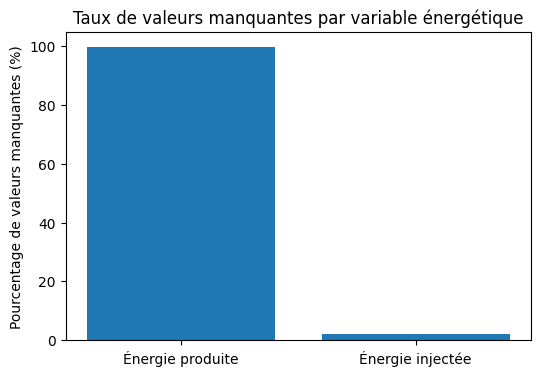

In [3]:
# Calcul du taux de valeurs manquantes
missing_rates = registre[['energieannuelleglissanteproduite',
                     'energieannuelleglissanteinjectee']].isna().astype(int).mean()

print(f"Pourcentage de valeurs manquantes par variables énergétique:\n{missing_rates * 100}")

labels = ['Énergie produite', 'Énergie injectée']

plt.figure(figsize=(6,4))
plt.bar(labels, missing_rates * 100)

# Titres et légendes
plt.title("Taux de valeurs manquantes par variable énergétique")
plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.show()

L'analyse exploratoire montre que la variable `energieAnnuelleGlissanteProduite` présente un taux très élevé de valeurs manquantes, contrairement à `energieAnnuelleGlissanteInjectee`, qui est disponible de manière homogène au sein de la base. Pour cette raison, l'énergie injectée est retenue comme indicateur principal, car elle constitue une mesure observable, complète et comparable entre territoires.

Dans le cadre de cette étude, la variable `energieAnnuelleGlissanteInjectee` est ainsi utilisée comme indicateur d'activité énergétique. Ce choix méthodologique est explicitement assumé et justifié par les caractéristiques de la base du Registre national des installations : la variable `energieAnnuelleGlissanteProduite`, qui correspond à l'énergie totale produite (incluant l'autoconsommation), n'est que très partiellement renseignée pour les installations photovoltaïques et ne permet pas de conduire une analyse statistique robuste à l'échelle territoriale.

L'énergie produite comprend à la fois (i) l'énergie injectée dans le réseau public et (ii) l'autoconsommation locale, qui n'est pas observée par les dispositifs de comptage réseau. Cependant, du point de vue du système électrique, seules les quantités effectivement injectées influencent les flux d'électricité, le dimensionnement des infrastructures et la planification des capacités de raccordement. Ainsi, l'analyse centrée sur l'énergie injectée permet de décrire ce que les installations font réellement au réseau, et non uniquement ce qu'elles produisent physiquement.

Par ailleurs, l'énergie injectée dans le réseau est issue de mesures de comptage réalisées par les gestionnaires de réseau et constitue une donnée disponible de manière homogène et cohérente sur l'ensemble du territoire. L'utilisation de cet indicateur garantit ainsi (i) la complétude des observations et l'absence de biais liés aux valeurs manquantes, (ii) la comparabilité entre communes et territoires, et (iii) une lecture fidèle de l'impact des installations sur le système électrique.


## Gestion des données incomplètes

Cette section regroupe l'analyse et le traitement des enregistrements pour lesquels certaines
informations géographiques ou énergétiques sont manquantes. L'objectif est de documenter les
choix de filtrage et d'exclusion afin de garantir la cohérence des analyses réalisées à la maille communale.

### Analyse exploratoire des enregistrements sans commune

Avant de réaliser les analyses à la maille communale, il est nécessaire d'examiner les enregistrements pour lesquels la variable `commune` n'est pas renseignée. On s'intéresse en particulier aux champs `commune`, `codeinseecommune` et `codeiris` afin de vérifier si l'absence de libellé communal est accompagnée ou non d'une absence d'identifiant géographique associé.

In [4]:
# vérification des valeurs manquantes sur les 3 variables
registre.loc[registre['commune'].isna(), ['commune', 'codeinseecommune', 'codeiris']].isna().sum()

commune             45
codeinseecommune    45
codeiris            45
dtype: int64

Les résultats montrent que les trois variables `commune`, `codeinseecommune` et `codeiris` présentent chacune **45 valeurs manquantes** pour les mêmes enregistrements. Autrement dit, pour ces 45 lignes, la commune n'est pas renseignée, et aucun identifiant géographique fin (ni code INSEE, ni code IRIS) n'est disponible. Il s'agit donc d'entrées pour lesquelles le registre ne fournit pas de localisation à la maille communale.

La variable `nbinstallations` correspond au nombre d'installations photovoltaïques regroupées dans un même enregistrement. Son analyse permet de déterminer si les lignes sans information communale correspondent à des **données agrégées** ou à des **installations individuelles**.

In [5]:
# vérifier le caractère agrégé via nbinstallations
print(registre[registre['commune'].isna()]['nbinstallations'].unique())

[ 63  12  56  70  83  10  52  21  31  45  29  59  74 106  96  40  18  27
  36 104  65  34  14  95  51  73 139  61  25  41  42  22 178  13  33  15]


L'examen de la variable `nbinstallations` pour ces mêmes enregistrements montre que toutes les valeurs sont strictement supérieures à 1. Ces lignes correspondent donc à des entrées **agrégées**, dans lesquelles plusieurs installations sont regroupées au sein d'un même enregistrement (`nbinstallations` > 1), sans localisation explicite à la maille communale.

In [6]:
# Calcul de la part de l'énergie injectée associée aux enregistrements sans information de commune
part_sans_commune = round(
    registre.loc[registre['commune'].isna(), 'energieannuelleglissanteinjectee'].sum()
    * 100 / registre['energieannuelleglissanteinjectee'].sum(),
    4
)

# Affichage du pourcentage d'énergie injectée correspondant aux lignes sans commune
print(part_sans_commune)

# Suppression des enregistrements pour lesquels la commune n'est pas renseignée
registre = registre.dropna(subset=["commune"])


0.2488


**Conclusion:**
La variable `commune` présente 45 valeurs manquantes. L'analyse de ces enregistrements montre qu'ils correspondent à des entrées **agrégées**, dans lesquelles plusieurs installations sont regroupées (`nbinstallations` > 1). Dans ces cas, le registre ne fournit pas systématiquement un libellé de commune et la localisation est renseignée à un niveau géographique supérieur (absence simultanée de `commune`, `codeinseecommune` et `codeiris`).

Dans ce contexte, ces lignes ne peuvent pas être intégrées de manière cohérente dans une analyse réalisée à la maille communale. Elles ont donc été **exclues des analyses communales et du calcul des communes représentatives**. Par ailleurs, elles ne représentent qu'environ **0,25 % de l'énergie injectée totale**, de sorte que leur exclusion n'affecte pas significativement les résultats globaux de l'étude.

### Manipulation des Valeurs manquantes

In [7]:
# Calcul du taux de valeurs manquantes pour chaque variable du DataFrame
missing_ratio = registre.isna().mean()

# Identification des variables dont plus de 25 % des valeurs sont manquantes
variables_to_drop = missing_ratio[missing_ratio > 0.25].index

# Affichage de la liste des variables à supprimer
print(variables_to_drop)

# Suppression des variables présentant trop de valeurs manquantes
registre = registre.drop(columns=variables_to_drop)


Index(['idpeps', 'codeeicresourceobject', 'codeiriscommuneimplantation',
       'codeinseecommuneimplantation', 'codes3renr', 'datederaccordement',
       'datedebutversion', 'postesource', 'moderaccordement',
       'codecombustible', 'combustible', 'codescombustiblessecondaires',
       'combustiblessecondaires', 'typestockage', 'puismaxraccharge',
       'puismaxcharge', 'puismaxinstalleedischarge', 'nbgroupes', 'regime',
       'codegestionnaire', 'gestionnaire', 'energieannuelleglissanteproduite',
       'energieannuelleglissantesoutiree', 'energieannuelleglissantestockee'],
      dtype='object')


### Traitement des valeurs manquantes sur `energieAnnuelleGlissanteInjectee`

In [8]:
# Sélection des lignes avec énergie injectée manquante
na_energy = registre[registre["energieannuelleglissanteinjectee"].isna()]
print("Nombre de lignes manquantes dans énergie injectée:", len(na_energy))

print("\nRésumé de nbinstallations :")
print(na_energy["nbinstallations"].describe())

# Évaluation de l'impact énergétique
puis_missing = na_energy["puismaxinstallee"].sum()
puis_total   = registre["puismaxinstallee"].sum()
part_puissance = puis_missing * 100 / puis_total

print(f"\nPuissance totale = {puis_total:.2f}")
print(f"Puissance associée aux valeurs manquantes = {puis_missing:.2f}")
print(f"Part de puissance concernée = {part_puissance:.2f} %")

# Exclusion des lignes manquantes pour la suite des analyses
registre = registre.loc[~registre["energieannuelleglissanteinjectee"].isna()].copy()


Nombre de lignes manquantes dans énergie injectée: 149

Résumé de nbinstallations :
count    149.000000
mean       2.288591
std       14.320792
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max      175.000000
Name: nbinstallations, dtype: float64

Puissance totale = 2807215.66
Puissance associée aux valeurs manquantes = 47990.47
Part de puissance concernée = 1.71 %


Une analyse exploratoire a été menée sur les 149 enregistrements dépourvus de
valeur pour la variable `energieAnnuelleGlissanteInjectee`. Ces lignes correspondent majoritairement à des installations unitaires, réparties sur plusieurs communes. Cette absence de données peut s'expliquer par le fait que ces sites ne disposent pas encore d'un historique d'injection glissante exploitable, ou qu'ils fonctionnent principalement en autoconsommation, avec peu ou pas d'énergie injectée sur le réseau.

Afin d'évaluer leur impact potentiel sur l'analyse énergétique, la puissance
installée associée à ces lignes a été comparée à la puissance totale du jeu de
données. Les installations concernées représentent **47,99 MW**, soit seulement
**1,70 % de la puissance photovoltaïque totale**. Leur contribution énergétique
étant marginale et impossible à estimer sans hypothèses fortes, ces
enregistrements ont été **exclus des analyses basées sur l'énergie injectée**,
de manière à garantir que les indicateurs reposent exclusivement sur des
valeurs observées et mesurées.

## Préparation et nettoyage des données

### Suppression des enregistrements dupliqués

Les enregistrements dupliqués sont supprimés afin d'éviter la double comptabilisation d'une même installation ou unité statistique.

In [9]:
# Nettoyage doublons
registre = registre.drop_duplicates()

### Filtrage des valeurs d'énergie injectée négatives

Une première étape de nettoyage consiste à identifier et exclure les enregistrements présentant une valeur négative de `energieannuelleglissanteinjectee`. De telles valeurs ne sont pas physiquement interprétables pour une énergie injectée sur 12 mois glissants et peuvent correspondre à des erreurs de saisie ou d'agrégation dans la base. Les observations concernées sont comptabilisées, puis retirées du jeu de données avant la poursuite de l'analyse.

In [10]:
# Comptage des observations présentant une énergie injectée négative
print(
    f"Nombre d'observations avec énergie négative = "
    f"{len(registre[registre.energieannuelleglissanteinjectee < 0])}"
)

# Vérification des dates de mise en service associées à ces observations
display(
    registre.loc[registre.energieannuelleglissanteinjectee < 0, 'datemiseenservice_date']
)


Nombre d'observations avec énergie négative = 1


5112    2009-09-25
Name: datemiseenservice_date, dtype: object

L'examen des dates de mise en service associées à ces observations montre qu'elles correspondent à des installations très anciennes (mise en service en 2009). Compte tenu de leur faible représentativité temporelle et du caractère non cohérent des valeurs énergétiques associées, ces enregistrements sont retirés du jeu de données afin de garantir la fiabilité des analyses ultérieures.

In [11]:
# Suppression des enregistrements présentant une énergie injectée négative
registre = registre.loc[registre.energieannuelleglissanteinjectee >= 0]

### Harmonisation du libellé de la commune “Marseille”

L'inspection de la variable `commune` révèle que **Marseille** apparaît sous plusieurs libellés correspondant aux arrondissements municipaux. Ces variantes sont regroupées sous une dénomination unique (`"Marseille"`) et le code INSEE correspondant est synchronisé afin d'éviter une fragmentation artificielle de la commune dans l'analyse territoriale.

In [12]:
# Identification des enregistrements dont le nom de commune contient "Marseille"
# (afin de regrouper les différentes écritures ou variantes orthographiques)
mask = registre["commune"].str.contains("marseille", case=False, na=False)

# Vérification des différentes valeurs détectées pour la commune de Marseille
print(registre.commune.loc[mask].unique())

# Harmonisation du nom de la commune : toutes les variantes sont renommées "Marseille"
registre.loc[mask, "commune"] = "Marseille"

# Récupération du code INSEE officiel de la commune de Marseille depuis la table des communes
marseille_insee = communes.loc[communes.nom == "Marseille", "code_insee"].iloc[0]

# Synchronisation du code INSEE pour toutes les lignes correspondant à la commune de Marseille
registre.loc[registre.commune == "Marseille", "codeinseecommune"] = marseille_insee



['Marseille 3e Arrondissement' 'Marseille 10e Arrondissement'
 'Marseille 4e Arrondissement' 'Marseille 11e Arrondissement'
 'Marseille 14e Arrondissement' 'Marseille 16e Arrondissement'
 'Marseille 15e Arrondissement' 'Marseille 13e Arrondissement'
 'Marseille 9e Arrondissement' 'Marseille 12e Arrondissement'
 'Marseille 8e Arrondissement' 'Marseille 2e Arrondissement'
 'Marseille 5e Arrondissement' 'Marseille 7e Arrondissement']


### Nettoyage / typage des colonnes
Nettoyage des types : harmonisation des types numériques des codes INSEE afin d'assurer des opérations fiables de jointure et d'agrégation sur l'ensemble du jeu de données.

In [13]:
# Conversion du code INSEE de la commune en type entier
registre["codeinseecommune"] = pd.to_numeric(registre["codeinseecommune"], errors="coerce").astype("int")

# Conversion du code INSEE dans la table des communes en type entier
communes["code_insee"] = pd.to_numeric(communes["code_insee"], errors="coerce").astype("int")


### Agrégation de l'énergie par commune
Agrégation : somme de l'énergie injectée par **commune** (code INSEE + nom), pour obtenir une énergie totale par commune.

In [14]:
agg = (
    registre.groupby(["codeinseecommune", "commune"], as_index=False)["energieannuelleglissanteinjectee"]
       .sum()
       .rename(columns={"energieannuelleglissanteinjectee": "energie_totale"})
)


### Jointure avec les coordonnées géographiques
Jointure avec les coordonnées géographiques (lat/lon) des communes, suppression des communes sans coordonnées et conversion des coordonnées en float.

In [15]:
# Jointure entre les données agrégées et la table des communes
# afin d'ajouter les coordonnées géographiques (latitude et longitude)
agg_geo = agg.merge(
    communes[["code_insee", "lat", "lon"]],
    left_on="codeinseecommune",
    right_on="code_insee",
    how="left"
)

# Suppression des communes pour lesquelles les coordonnées géographiques sont manquantes
agg_geo = agg_geo.dropna(subset=["lat", "lon"]).copy()

# Conversion explicite des coordonnées en type float
# (nécessaire pour les traitements géographiques et les visualisations)
agg_geo["lat"] = agg_geo["lat"].astype(float)
agg_geo["lon"] = agg_geo["lon"].astype(float)

# Affichage du nombre de communes disposant de coordonnées exploitables
print("Nombre de communes avec coordonnées :", agg_geo.shape[0])


Nombre de communes avec coordonnées : 784


## Clustering géographique (KMeans sur lat/lon)
Clustering géographique : application de **KMeans** sur (lat, lon) pour regrouper les communes en zones spatiales, puis attribution d'un identifiant de cluster à chaque commune.

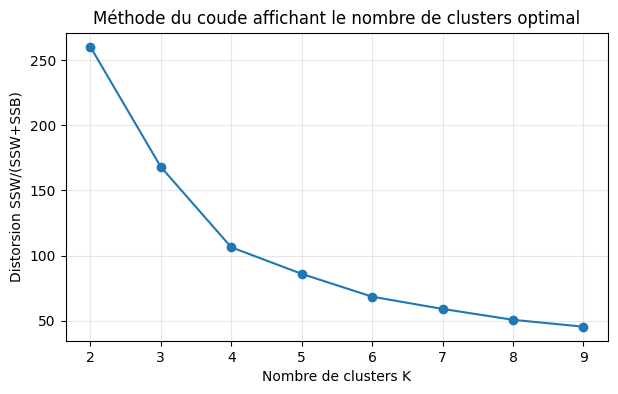


Répartition des communes par cluster géographique :
cluster_geo
3    199
1    159
2    156
0    148
4    122
Name: count, dtype: int64


In [16]:
# Extraction des coordonnées géographiques (latitude, longitude)
# Ces variables serviront de base au clustering spatial
X_geo = agg_geo[["lat", "lon"]].values

# Définition du nombre initial de clusters géographiques
k_geo = 5
kmeans_geo = KMeans(n_clusters=k_geo, random_state=42)

# Entraînement KMeans sur les données géographiques
kmeans_geo.fit(X_geo)

# Assignation du cluster à chaque commune
agg_geo["cluster_geo"] = kmeans_geo.predict(X_geo)

# Méthode du coude
inertias = []
K_values = range(2, 10)

for k in K_values:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    kmeans.fit(X_geo)
    inertias.append(kmeans.inertia_)

# Visualisation de la méthode du coude
plt.figure(figsize=(7,4))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("Nombre de clusters K")
plt.ylabel('Distorsion SSW/(SSW+SSB)')
plt.title("Méthode du coude affichant le nombre de clusters optimal")
plt.grid(alpha=0.3)
plt.show()

# Affichage de la répartition des communes par cluster géographique
print("\nRépartition des communes par cluster géographique :")
print(agg_geo["cluster_geo"].value_counts())


Le nombre de clusters n'a pas été choisi selon un critère purement
algorithmique, mais en fonction de l'objectif de l'étude : représenter la région au moyen d'un
nombre limité de communes représentatives. Un nombre trop élevé de clusters impliquerait
le téléchargement et le traitement d'un volume de données météorologiques trop important
pour chaque commune. **K = 5** est un bon compromis : il évite de découper la région en trop de zones tout en permettant d'en distinguer plusieurs de manière pertinente.
La courbe du coude ne choisit pas K = 5, mais elle montre que ce choix est cohérent avec la structure des données.

## Contribution énergétique de chaque cluster
Agrégation : somme de l'énergie injectée par **commune** (code INSEE + nom), pour obtenir une énergie totale par commune.

In [17]:
# Agrégation de l'énergie totale par cluster géographique
# On calcule la somme de l'énergie produite/injectée pour chaque cluster
cluster_energy = (
    agg_geo.groupby("cluster_geo", as_index=False)["energie_totale"]
           .sum()
           .rename(columns={"energie_totale": "energie_cluster"})
)

# Calcul de l'énergie totale sur l'ensemble de la région
total_energy = cluster_energy["energie_cluster"].sum()

# Calcul de la contribution de chaque cluster en pourcentage
cluster_energy["part_pourcent"] = 100 * cluster_energy["energie_cluster"] / total_energy

# Calcul du poids relatif de chaque cluster (valeur normalisée entre 0 et 1)
cluster_energy["poids"] = round(cluster_energy["part_pourcent"] / 100, 2)

# Affichage de la contribution énergétique de chaque cluster géographique
print("\nContribution énergétique de chaque cluster géographique :")
print(cluster_energy)



Contribution énergétique de chaque cluster géographique :
   cluster_geo  energie_cluster  part_pourcent  poids
0            0     2.330795e+08       7.381074   0.07
1            1     9.071664e+08      28.727798   0.29
2            2     7.048656e+08      22.321413   0.22
3            3     1.129808e+09      35.778325   0.36
4            4     1.828805e+08       5.791390   0.06


### Centroïde pondéré par l'énergie et commune représentative la plus proche
Pour chaque cluster :
1. Calcul du **centre de gravité énergétique** (moyenne pondérée des coordonnées).
2. Choix de la **commune la plus proche** de ce centre (distance euclidienne sur (lon, lat)).

<div class="remark remark-info">
<i class="fa fa-info-circle"></i> &emsp;
La fonction <code>np.average</code> est utilisée pour le calcul des moyennes pondérées.  
Contrairement à <code>np.mean</code>, elle permet d'associer un <strong>poids</strong> à chaque valeur, de sorte que les observations contribuent au résultat proportionnellement à leur importance.  
En l'absence de poids, <code>np.average</code>` se réduit à une moyenne arithmétique classique.
</div>

In [18]:
# Liste destinée à stocker la commune représentative de chaque cluster géographique
best_communes = []

# Parcours de chaque cluster géographique
for g in agg_geo["cluster_geo"].unique():

    # Sous-ensemble des communes appartenant au cluster g
    subset = agg_geo[agg_geo["cluster_geo"] == g].copy()

    # Calcul du centroïde énergétique du cluster
    # Il s'agit d'un centre de gravité géographique pondéré par l'énergie totale
    lon_center = np.average(
        subset["lon"],
        weights=subset["energie_totale"]
    )
    lat_center = np.average(
        subset["lat"],
        weights=subset["energie_totale"]
    )

    # Calcul de la distance de chaque commune au centroïde énergétique
    subset["distance"] = np.sqrt(
        (subset["lon"] - lon_center) ** 2
        + (subset["lat"] - lat_center) ** 2
    )

    # Identification de la commune la plus proche du centroïde
    # Cette commune est considérée comme la plus représentative du cluster
    best_row = subset.loc[subset["distance"].idxmin()]

    # Stockage des informations de la commune sélectionnée
    best_communes.append({
        "cluster_geo": g,
        "best_commune": best_row["commune"],
        "code_insee": best_row["codeinseecommune"],
        "lat": best_row["lat"],
        "lon": best_row["lon"],
        "energie_totale": best_row["energie_totale"]
    })

# Création d'un DataFrame récapitulatif des communes représentatives
best_communes_df = pd.DataFrame(best_communes)

# Ajout du poids énergétique de chaque cluster
best_communes_df = best_communes_df.merge(
    cluster_energy[["cluster_geo", "poids"]],
    on="cluster_geo",
    how="left"
)

# Affichage du résultat final
print("\nMeilleure commune par cluster géographique (centre de gravité énergétique) :")
print(best_communes_df)



Meilleure commune par cluster géographique (centre de gravité énergétique) :
   cluster_geo            best_commune  code_insee      lat     lon  \
0            2                   Cruis        4065  44.0845  5.8397   
1            4   Saint-Étienne-le-Laus        5140  44.5075  6.1616   
2            0  Saint-Vallier-de-Thiey        6130  43.6994  6.8516   
3            1                    Bras       83021  43.4723  5.9558   
4            3              Eygalières       13034  43.7638  4.9554   

   energie_totale  poids  
0      20356525.0   0.22  
1        325158.0   0.06  
2        344281.0   0.07  
3      10603661.0   0.29  
4       1510927.0   0.36  


## Chargement du fond de carte PACA
Chargement du fond de carte PACA (GeoJSON) et mise au bon système de coordonnées **WGS84 (EPSG:4326)** pour superposer correctement les points (lon/lat).

In [19]:
# Chargement du fichier GeoJSON contenant le contour géographique de la région PACA
paca = gpd.read_file("../../data/local_data/01_Clustering/input/region_paca.geojson")

# Vérification et harmonisation du système de coordonnées géographiques
# L'objectif est de travailler en WGS84 (EPSG:4326), compatible avec les coordonnées (longitude, latitude)
if paca.crs is None:
    # Si aucun système de coordonnées n'est défini, on l'assigne explicitement à WGS84
    paca.set_crs(epsg=4326, inplace=True)
else:
    # Si un système de coordonnées existe, on reprojette vers WGS84
    paca = paca.to_crs(epsg=4326)


## Visualisation (fond de carte PACA + clusters + communes représentatives)
Une fois le fond cartographique harmonisé dans le système de coordonnées WGS84, il peut être utilisé pour superposer les données communales et visualiser spatialement les clusters géographiques ainsi que leur contribution énergétique.

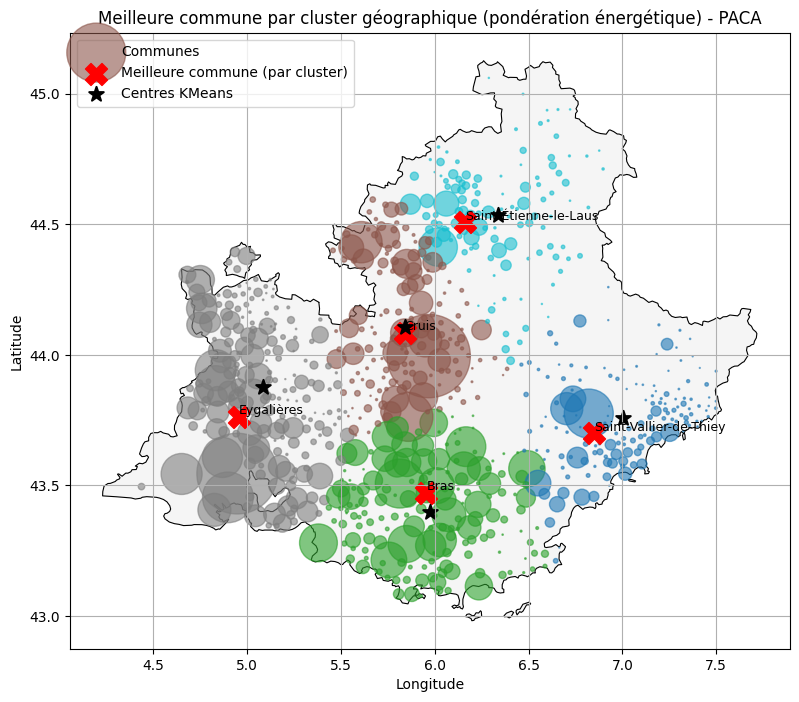

In [20]:
# Création de la figure et des axes pour la visualisation cartographique
fig, ax = plt.subplots(figsize=(10, 8))

# Affichage du fond de carte de la région PACA
paca.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=0.8)

# Définition de la taille des points proportionnellement à l'énergie totale
# (le facteur de division améliore la lisibilité de la carte)
point_sizes = agg_geo["energie_totale"] / 50000

# Représentation des communes
# - la couleur correspond au cluster géographique
# - la taille des points est proportionnelle à l'énergie totale
scatter_communes = ax.scatter(
    agg_geo["lon"],
    agg_geo["lat"],
    c=agg_geo["cluster_geo"],
    s=point_sizes,
    alpha=0.6,
    cmap="tab10",
    label="Communes"
)

# Mise en évidence des communes représentatives de chaque cluster
# (communes les plus proches du centroïde énergétique)
ax.scatter(
    best_communes_df["lon"],
    best_communes_df["lat"],
    c="red",
    s=250,
    marker="X",
    label="Meilleure commune (par cluster)"
)

# Affichage des centroïdes issus de l'algorithme KMeans
# cluster_centers_ est fourni sous la forme [latitude, longitude]
centroids = kmeans_geo.cluster_centers_
ax.scatter(
    centroids[:, 1],  # longitude
    centroids[:, 0],  # latitude
    marker="*",
    c='black',
    s=120,
    edgecolors="black",
    linewidths=1.5,
    label="Centres KMeans"
)

# Annotation des noms des communes représentatives
for _, row in best_communes_df.iterrows():
    ax.text(row["lon"], row["lat"], row["best_commune"],
            fontsize=9, ha="left", va="bottom")

ax.set_title("Meilleure commune par cluster géographique (pondération énergétique) - PACA")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)
ax.legend(loc="upper left")

# Sauvegarde de la figure
plt.savefig("../../data/local_data/01_Clustering/output/carte_paca_communes.png", dpi=600, bbox_inches="tight")
plt.show()


## Insertion d'un préfixe pour chaque commune

Pour faciliter l'exploitation ultérieure des données géographiques, on remplace le nom de villes sélectionnées par un code sur trois lettres :    

 - Cruis est encodé par 'CRU' ;
 - Saint-Étienne-le-Laus par 'SEL' ;
 - Saint-Vallier-de-Thiey par 'SVT' ;
 - Bras par 'BRA' ;
 - Eygalières par 'EYG'.

In [21]:
best_communes_df['prefix'] = 'CRU'
best_communes_df.loc[best_communes_df['best_commune']=='Saint-Étienne-le-Laus', 'prefix'] = 'SEL'
best_communes_df.loc[best_communes_df['best_commune']=='Saint-Vallier-de-Thiey', 'prefix'] = 'SVT'
best_communes_df.loc[best_communes_df['best_commune']=='Bras', 'prefix'] = 'BRA'
best_communes_df.loc[best_communes_df['best_commune']=='Eygalières', 'prefix'] = 'EYG'

display(best_communes_df.head())

,cluster_geo,best_commune,code_insee,lat,lon,energie_totale,poids,prefix
0,2,Cruis,4065,44.0845,5.8397,20356525.0,0.22,CRU
1,4,Saint-Étienne-le-Laus,5140,44.5075,6.1616,325158.0,0.06,SEL
2,0,Saint-Vallier-de-Thiey,6130,43.6994,6.8516,344281.0,0.07,SVT
3,1,Bras,83021,43.4723,5.9558,10603661.0,0.29,BRA
4,3,Eygalières,13034,43.7638,4.9554,1510927.0,0.36,EYG


## Sauvegarde des résultats
Export : sauvegarde du tableau final des meilleures communes par cluster (avec poids) au format CSV.

In [22]:
best_communes_df.to_csv("../../data/local_data/01_Clustering/output/best_communes_geo_energy.csv", index=False)

# Vérification
print("\nFichier sauvegardé : best_communes_geo_energy.csv")



Fichier sauvegardé : best_communes_geo_energy.csv


## Conclusion méthodologique

Le protocole mis en place permet de sélectionner un ensemble réduit de communes représentatives
à partir d'une logique à la fois énergétique et territoriale. Les centroïdes géographiques sont
pondérés par l'énergie injectée, ce qui garantit que la contribution réelle des communes au sein
de chaque cluster est correctement prise en compte. La gestion explicite des données manquantes
et le choix raisonné de K = 5 assurent une partition du territoire qui reste interprétable tout en
réduisant le nombre de communes à traiter pour les analyses météorologiques associées.
